In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers, models, regularizers

from tensorflow.keras.applications import DenseNet169
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 2. Configurações

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 0.0001
TEST_SIZE = 0.20
VAL_SIZE = 0.20

USE_DULL_RAZOR = True
USE_MASK_SEGMENTATION = True

USE_MASK_CROP = False
CROP_MARGIN = 20

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)
print("USE_DULL_RAZOR:", USE_DULL_RAZOR)
print("USE_MASK_SEGMENTATION:", USE_MASK_SEGMENTATION)
print("USE_MASK_CROP:", USE_MASK_CROP)
print(class_code)

IMG_SIZE: (256, 256)
BATCH_SIZE: 32
EPOCHS: 200
LEARNING_RATE: 0.0001
USE_DULL_RAZOR: True
USE_MASK_SEGMENTATION: True
USE_MASK_CROP: False
{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


In [3]:
def find_file(directory, base_name, extensions):
    for extension in extensions:
        path = directory / f"{base_name}{extension}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_mask.jpg",
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_file(IMAGES_DIR, image_id, [".jpg", ".jpeg", ".png"])
    mask_path = find_mask_path(image_id, MASKS_DIR)

    if image_path is None or mask_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

print("Total de pares imagem/máscara localizados:", len(df))
display(df.head())

print("\nDistribuição original:")
print(df["class_name"].value_counts().reindex(classes))

print("\nMáscaras encontradas:", df["mask_path"].notna().sum())

Total de pares imagem/máscara localizados: 10015


,image,image_path,mask_path,class_name,label
0,ISIC_0024306,../data/images/ISIC_0024306.jpg,../data/masks/ISIC_0024306_segmentation.png,NV,1
1,ISIC_0024307,../data/images/ISIC_0024307.jpg,../data/masks/ISIC_0024307_segmentation.png,NV,1
2,ISIC_0024308,../data/images/ISIC_0024308.jpg,../data/masks/ISIC_0024308_segmentation.png,NV,1
3,ISIC_0024309,../data/images/ISIC_0024309.jpg,../data/masks/ISIC_0024309_segmentation.png,NV,1
4,ISIC_0024310,../data/images/ISIC_0024310.jpg,../data/masks/ISIC_0024310_segmentation.png,MEL,0



Distribuição original:
class_name
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64

Máscaras encontradas: 10015


In [4]:
def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")

    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def read_mask(mask_path, target_shape=None):
    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        raise ValueError(f"Não foi possível carregar a máscara: {mask_path}")

    if target_shape is not None:
        height, width = target_shape[:2]
        mask = cv2.resize(mask, (width, height))

    binary_mask = (mask > 127).astype(np.uint8)

    return binary_mask


def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)

    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)

    _, mask = cv2.threshold(
        blackhat_blur,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    clean_bgr = cv2.inpaint(
        image_bgr,
        mask,
        inpaint_radius,
        cv2.INPAINT_TELEA
    )

    clean_rgb = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)

    return clean_rgb


def apply_mask_segmentation(image_rgb, mask_path):
    binary_mask = read_mask(mask_path, target_shape=image_rgb.shape)

    segmented = image_rgb * np.expand_dims(binary_mask, axis=-1)

    # Proteção contra máscara ruim: evita imagem totalmente preta.
    if np.mean(segmented) < 5:
        return image_rgb

    return segmented


def crop_lesion_with_margin(image_rgb, mask_path, margin=CROP_MARGIN):
    binary_mask = read_mask(mask_path, target_shape=image_rgb.shape)

    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return image_rgb

    height, width = image_rgb.shape[:2]

    x_min = max(xs.min() - margin, 0)
    x_max = min(xs.max() + margin, width - 1)
    y_min = max(ys.min() - margin, 0)
    y_max = min(ys.max() + margin, height - 1)

    cropped = image_rgb[y_min:y_max + 1, x_min:x_max + 1]

    if cropped.size == 0:
        return image_rgb

    return cropped


def preprocess_segmented_image(image_path, mask_path):
    image_rgb = read_rgb_image(image_path)

    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)

    if USE_MASK_SEGMENTATION:
        if USE_MASK_CROP:
            image_rgb = crop_lesion_with_margin(image_rgb, mask_path)
        else:
            image_rgb = apply_mask_segmentation(image_rgb, mask_path)

    image_rgb = cv2.resize(image_rgb, IMG_SIZE)

    return image_rgb.astype("float32")

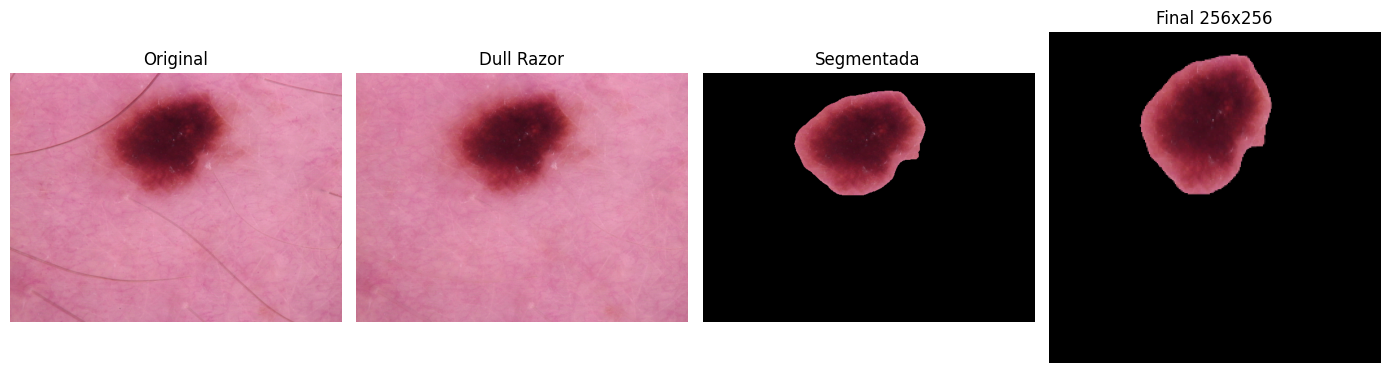

In [5]:
sample_row = df.sample(1, random_state=SEED).iloc[0]

original = read_rgb_image(sample_row["image_path"])
dull = dull_razor_remove_hair(original) if USE_DULL_RAZOR else original
segmented = apply_mask_segmentation(dull, sample_row["mask_path"])
final_image = preprocess_segmented_image(sample_row["image_path"], sample_row["mask_path"])
final_image = np.clip(final_image, 0, 255).astype("uint8")

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(dull)
plt.title("Dull Razor")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(np.clip(segmented, 0, 255).astype("uint8"))
plt.title("Segmentada")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(final_image)
plt.title("Final 256x256")
plt.axis("off")

plt.tight_layout()
plt.savefig("pipeline_segmentado_dull_razor.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

print("Treino original:", len(train_df))
print("Teste final:", len(test_df))

print("\nDistribuição treino antes do undersampling:")
print(train_df["class_name"].value_counts().reindex(classes))


def apply_undersampling(dataframe, label_column="label", random_state=SEED):
    counts = dataframe[label_column].value_counts()
    min_count = counts.min()

    balanced_parts = []

    for label_value in sorted(counts.index):
        class_df = dataframe[dataframe[label_column] == label_value]
        sampled_df = class_df.sample(
            n=min_count,
            random_state=random_state,
            replace=False
        )
        balanced_parts.append(sampled_df)

    balanced_df = pd.concat(balanced_parts, axis=0)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return balanced_df


train_under_df = apply_undersampling(train_df)

print("\nTreino após undersampling:", len(train_under_df))
print(train_under_df["class_name"].value_counts().reindex(classes))

Treino original: 8012
Teste final: 2003

Distribuição treino antes do undersampling:
class_name
MEL       890
NV       5364
BCC       411
AKIEC     262
BKL       879
DF         92
VASC      114
Name: count, dtype: int64

Treino após undersampling: 644
class_name
MEL      92
NV       92
BCC      92
AKIEC    92
BKL      92
DF       92
VASC     92
Name: count, dtype: int64


In [7]:
train_fit_df, val_df = train_test_split(
    train_under_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_under_df["label"]
)

print("Treino usado no fit:", len(train_fit_df))
print("Validação:", len(val_df))
print("Teste final:", len(test_df))

print("\nDistribuição treino final:")
print(train_fit_df["class_name"].value_counts().reindex(classes))

print("\nDistribuição validação:")
print(val_df["class_name"].value_counts().reindex(classes))

Treino usado no fit: 515
Validação: 129
Teste final: 2003

Distribuição treino final:
class_name
MEL      74
NV       74
BCC      74
AKIEC    73
BKL      73
DF       74
VASC     73
Name: count, dtype: int64

Distribuição validação:
class_name
MEL      18
NV       18
BCC      18
AKIEC    19
BKL      19
DF       18
VASC     19
Name: count, dtype: int64


In [8]:
def load_image_for_training_py(image_path, mask_path, label):
    if isinstance(image_path, bytes):
        image_path = image_path.decode("utf-8")

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    image = preprocess_segmented_image(image_path, mask_path)

    return image.astype("float32"), np.int32(label)


def tf_load_image_for_training(image_path, mask_path, label):
    image, label = tf.numpy_function(
        load_image_for_training_py,
        [image_path, mask_path, label],
        [tf.float32, tf.int32]
    )

    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    label.set_shape(())

    return image, label


def build_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["image_path"].astype(str).values,
        dataframe["mask_path"].astype(str).values,
        dataframe["label"].values.astype("int32")
    ))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(tf_load_image_for_training, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = build_dataset(train_fit_df, shuffle=True)
val_ds = build_dataset(val_df, shuffle=False)
test_ds = build_dataset(test_df, shuffle=False)

print(train_ds)
print(val_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [9]:
BEST_MODEL_PATH = "best_segmented_densenet169_dull_undersampling.keras"
FINAL_MODEL_PATH = "segmented_densenet169_dull_undersampling_final.keras"


def build_densenet169_model(num_classes=len(classes), input_shape=(256, 256, 3)):
    base_model = DenseNet169(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = preprocess_input(inputs)
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="segmented_densenet169_dull_undersampling"
    )

    return model, base_model


model, base_model = build_densenet169_model(
    num_classes=len(classes),
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "segmented_densenet169_dull_undersampling"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 8, 8, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       426,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,103,943 (49.99 MB)

 Trainable params: 460,551 (1.76 MB)

 Non-trainable params: 12,643,392 (48.23 MB)

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.1505 - loss: 3.3760
Epoch 1: val_loss improved from None to 2.63072, saving model to best_segmented_densenet169_dull_undersampling.keras

Epoch 1: finished saving model to best_segmented_densenet169_dull_undersampling.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1456 - loss: 3.3384 - val_accuracy: 0.1395 - val_loss: 2.6307 - learning_rate: 1.0000e-04
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.2126 - loss: 3.0606
Epoch 2: val_loss improved from 2.63072 to 2.50757, saving model to best_segmented_densenet169_dull_undersampling.keras

Epoch 2: finished saving model to best_segmented_densenet169_dull_undersampling.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2214 - loss: 2.9333 - val_accuracy: 0.1860 - val_loss: 2.5076 - learning_rate: 1.0000e-04
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.2469 - loss: 2.8498
Epoch 3: val_loss improved from 2.50757 to

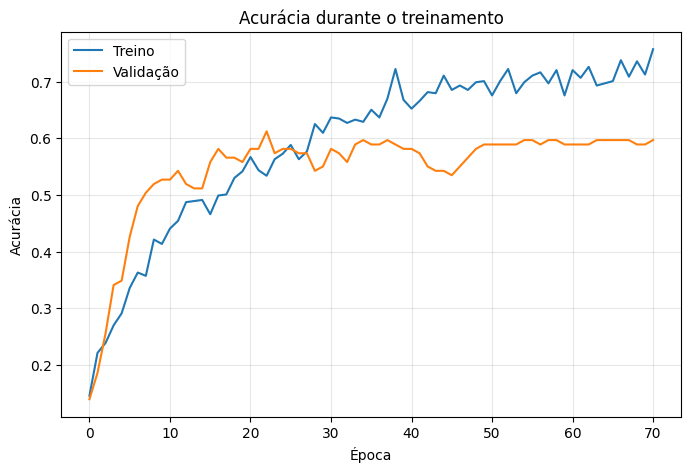

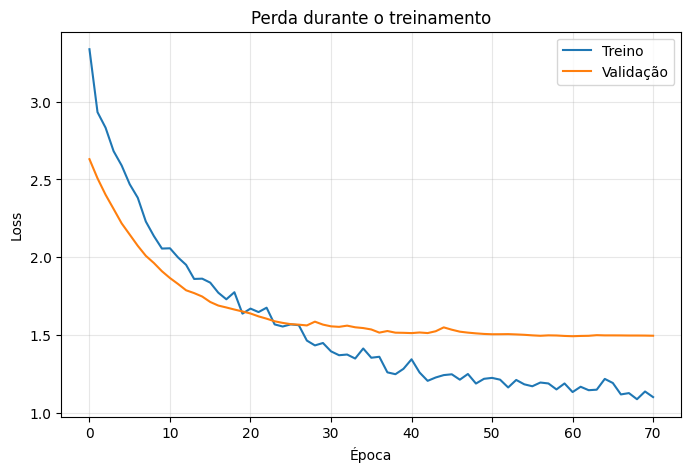

Relatório de Classificação:
              precision    recall  f1-score   support

         MEL     0.2973    0.4439    0.3561       223
          NV     0.9252    0.6458    0.7606      1341
         BCC     0.4161    0.5534    0.4750       103
       AKIEC     0.2384    0.5538    0.3333        65
         BKL     0.4135    0.3909    0.4019       220
          DF     0.1453    0.7391    0.2429        23
        VASC     0.1983    0.8571    0.3221        28

    accuracy                         0.5916      2003
   macro avg     0.3763    0.5977    0.4131      2003
weighted avg     0.7315    0.5916    0.6356      2003


MÉTRICAS GERAIS DO MODELO
Accuracy: 0.5916

Macro Average:
  Precision: 0.3763
  Recall: 0.5977
  F1-Score: 0.4131

Weighted Average:
  Precision: 0.7315
  Recall: 0.5916
  F1-Score: 0.6356


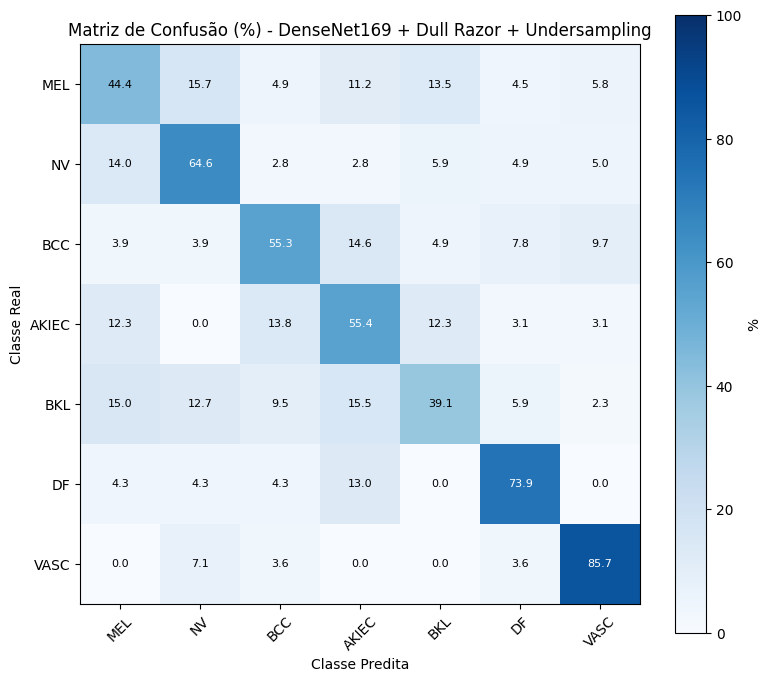

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("acuracia_segmented_densenet169_undersampling.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.title("Perda durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("loss_segmented_densenet169_undersampling.png", dpi=300, bbox_inches="tight")
plt.show()

best_model = keras.models.load_model(BEST_MODEL_PATH)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Relatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4, zero_division=0))

acc = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO MODELO")
print(f"Accuracy: {acc:.4f}")
print("\nMacro Average:")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall: {macro_recall:.4f}")
print(f"  F1-Score: {macro_f1:.4f}")
print("\nWeighted Average:")
print(f"  Precision: {weighted_precision:.4f}")
print(f"  Recall: {weighted_recall:.4f}")
print(f"  F1-Score: {weighted_f1:.4f}")

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
cm_percent = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100
cm_percent = np.nan_to_num(cm_percent)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
plt.title("Matriz de Confusão (%) - DenseNet169 + Dull Razor + Undersampling")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        color = "white" if cm_percent[i, j] > 50 else "black"
        plt.text(j, i, f"{cm_percent[i, j]:.1f}", ha="center", va="center", color=color, fontsize=8)

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_segmented_densenet169_undersampling.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
best_model.save(FINAL_MODEL_PATH)

print("Modelo final salvo em:", FINAL_MODEL_PATH)
print("Melhor checkpoint salvo em:", BEST_MODEL_PATH)

Modelo final salvo em: segmented_densenet169_dull_undersampling_final.keras
Melhor checkpoint salvo em: best_segmented_densenet169_dull_undersampling.keras
